# Training Three Binary Classification Models
This notebook trains three deep learning models for autonomous driving binary classification :
* Obstacle
* No Obstacle
The purpose is to train all models under the same setup and compare them then .


## Goal 
In this noetbook, I train 3 candidate models on the prepared dataset and evaluate  them using the same training and validation pipeline
The final comparision will help mme select the best model for the obstacle detection task

## Imports 
Loaad all the required libraries ,utility functions, model definitions, and training helpers used throughout the notebok

In [1]:
# Install the custom image processing library
!pip install git+https://github.com/gracyy-rm/cv-toolkit.git

  Cloning https://github.com/gracyy-rm/cv-toolkit.git to /tmp/pip-req-build-_8bm7g23
  Running command git clone --filter=blob:none --quiet https://github.com/gracyy-rm/cv-toolkit.git /tmp/pip-req-build-_8bm7g23
  Resolved https://github.com/gracyy-rm/cv-toolkit.git to commit 1b1c7770a63afd84ea506c869ae76b5b9905eba2
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for cvcore: filename=cvcore-0.1.0-py3-none-any.whl size=19541 sha256=d8417730f0293234bb4644e5169870d26e7a47b6336da8536207cf788bd303a8
  Stored in directory: /tmp/pip-ephem-wheel-cache-i5i3gglm/wheels/e4/6f/79/c08bdeebffbc3b53b8763cf4c5340df0d4de3e1a3a12ddf189
Successfully built cvcore


In [2]:
rm -rf src/__pycache__ __pycache__

In [3]:
!rm -rf autonomous-binary-classifier

In [4]:
#git clone
!git clone https://github.com/gracyy-rm/autonomous-binary-classifier.git

Cloning into 'autonomous-binary-classifier'...
remote: Enumerating objects: 537, done.
remote: Counting objects: 100% (39/39), done.
remote: Compressing objects: 100% (30/30), done.
remote: Total 537 (delta 19), reused 25 (delta 9), pack-reused 498 (from 2)
Receiving objects: 100% (537/537), 268.99 MiB | 20.16 MiB/s, done.
Resolving deltas: 100% (288/288), done.
Updating files: 100% (60/60), done.


In [5]:

import os 
import kagglehub
import os
import shutil
import random
import torch
import torchvision.transforms as T
from torch.utils.data import DataLoader
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from shapely.geometry import Polygon, box
import seaborn as sns
from tqdm import tqdm
import cvcore as cr
import sys
import json
sys.path.append("/kaggle/working/autonomous-binary-classifier")


In [6]:
from src.dataset import AutonomousBinaryDataset, get_data_transforms

## Paths and configuration
Define Dataset paths, models save paths , batch size, image_size, learning rate, number of epochs and other training settings 

In [7]:
os.chdir("/kaggle/working/autonomous-binary-classifier")

In [8]:
!pwd

/kaggle/working/autonomous-binary-classifier


In [9]:
train_df = pd.read_csv("/kaggle/input/datasets/gracyyadav79/final-csvs/ftrain.csv")
val_df = pd.read_csv("/kaggle/input/datasets/gracyyadav79/final-csvs/fval.csv")

In [10]:
import json

config_path = "config/config.json"

with open(config_path, "r") as f:
    config = json.load(f)

In [11]:
config["paths"]["train_csv"]="/kaggle/input/datasets/gracyyadav79/final-csvs/ftrain.csv"
config["paths"]["val_csv"] = "/kaggle/input/datasets/gracyyadav79/final-csvs/fval.csv"
config["paths"]["experiments_dir"] = "experiments"

In [12]:
config_path = "config/config.json"
with open(config_path, "w") as f:
    json.dump(config, f, indent=4)


In [13]:
config

{'paths': {'train_csv': '/kaggle/input/datasets/gracyyadav79/final-csvs/ftrain.csv',
  'val_csv': '/kaggle/input/datasets/gracyyadav79/final-csvs/fval.csv',
  'log_dir': 'logs/',
  'history_dir': 'training_histories/',
  'model_save_dir': 'saved_models/',
  'model_filename': 'best_efficientnet_b0_acc92.0.pthh',
  'model_path': '',
  'experiments_dir': 'experiments'},
 'model': {'architecture': 'resnet18',
  'pretrained': True,
  'num_classes': 1,
  'freeze_backbone': 'partial'},
 'classes': {'mapping': {'0': 'No_Obstacle', '1': 'Obstacle'}},
 'training_parameters': {'batch_size': 32,
  'learning_rate': 0.001,
  'epochs': 25,
  'image_size': 224,
  'seed': 1,
  'accumulation_steps': 2,
  'early_stopping_patience': 8,
  'weight_decay': 0.05,
  'pos_weights': 1.0},
 'hardware': {'num_workers': 4}}

## Dataset check 


In [14]:
train_df.head()

,image_path,image_name,raw_logit,raw_prob,label_encoded,label,confidence_score,is_uncertain
0,/kaggle/input/datasets/solesensei/solesensei_b...,b539383c-b57307bc.jpg,-3.1630,0.0406,0,No Obstacle,95.94,False
1,/kaggle/input/datasets/solesensei/solesensei_b...,c4a19ba6-e706bdc2.jpg,15.1743,1.0000,1,Obstacle,100.00,False
2,/kaggle/input/datasets/solesensei/solesensei_b...,b5e1a441-3bc3277c.jpg,9.9610,1.0000,1,Obstacle,100.00,False
3,/kaggle/input/datasets/solesensei/solesensei_b...,b5191523-af1c9a30.jpg,5.1471,0.9942,1,Obstacle,99.42,False
4,/kaggle/input/datasets/solesensei/solesensei_b...,bfc06497-fc2b4581.jpg,11.1871,1.0000,1,Obstacle,100.00,False


In [15]:
train_df["label"].value_counts()

label
No Obstacle    37637
Obstacle       36391
Name: count, dtype: int64

In [16]:
val_df.head()

,image_path,image_name,label,label_encoded
0,/kaggle/input/datasets/gracyyadav79/data-2k-50...,3cdd3c22-5e9f67a6.jpg,Obstacle,1
1,/kaggle/input/datasets/gracyyadav79/data-2k-50...,ac3c2886-ac6d0376.jpg,Obstacle,1
2,/kaggle/input/datasets/gracyyadav79/data-2k-50...,13796ade-6b89dc0d.jpg,Obstacle,1
3,/kaggle/input/datasets/gracyyadav79/data-2k-50...,899e09b2-f0a32d3d.jpg,Obstacle,1
4,/kaggle/input/datasets/gracyyadav79/data-2k-50...,9eb5163f-8f7a0a6b.jpg,Obstacle,1


In [17]:
val_df["label"].value_counts()

label
Obstacle       1324
No Obstacle     858
Name: count, dtype: int64

## Dataloader Setup

In [18]:
with open("config/config.json") as f:
    config = json.load(f)

In [19]:
img_size = config["training_parameters"]["image_size"]

In [20]:
train_transform, val_transform = get_data_transforms(img_size=img_size)

In [21]:
train_dataset = AutonomousBinaryDataset(df=train_df, transform=train_transform)
val_dataset = AutonomousBinaryDataset(df=val_df, transform=val_transform)

In [22]:
from torch.utils.data import DataLoader

batch_size = config["training_parameters"]["batch_size"] 
num_workers = config["hardware"]["num_workers"]          

# Create DataLoaders
train_loader = DataLoader(
    dataset=train_dataset,
    batch_size=batch_size,
    shuffle=True,       
    num_workers=num_workers,
    pin_memory=True     
)
val_loader = DataLoader(
    dataset=val_dataset,
    batch_size=batch_size,
    num_workers=num_workers,
    pin_memory=True
)


In [23]:
# extracting single sample from the piepline 
images, labels = next(iter(train_loader))

print("--- DataLoader Structural Verification ---")
print(f"Batch Image Shape : {images.shape}")  
print(f"Batch Label Shape : {labels.shape}") 
print(f"Labels Sample Array:\n{labels[:10]}") 

--- DataLoader Structural Verification ---
Batch Image Shape : torch.Size([32, 3, 224, 224])
Batch Label Shape : torch.Size([32])
Labels Sample Array:
tensor([0., 0., 1., 1., 0., 0., 0., 1., 1., 1.])


## Dataloader visualizer

**train_loader**

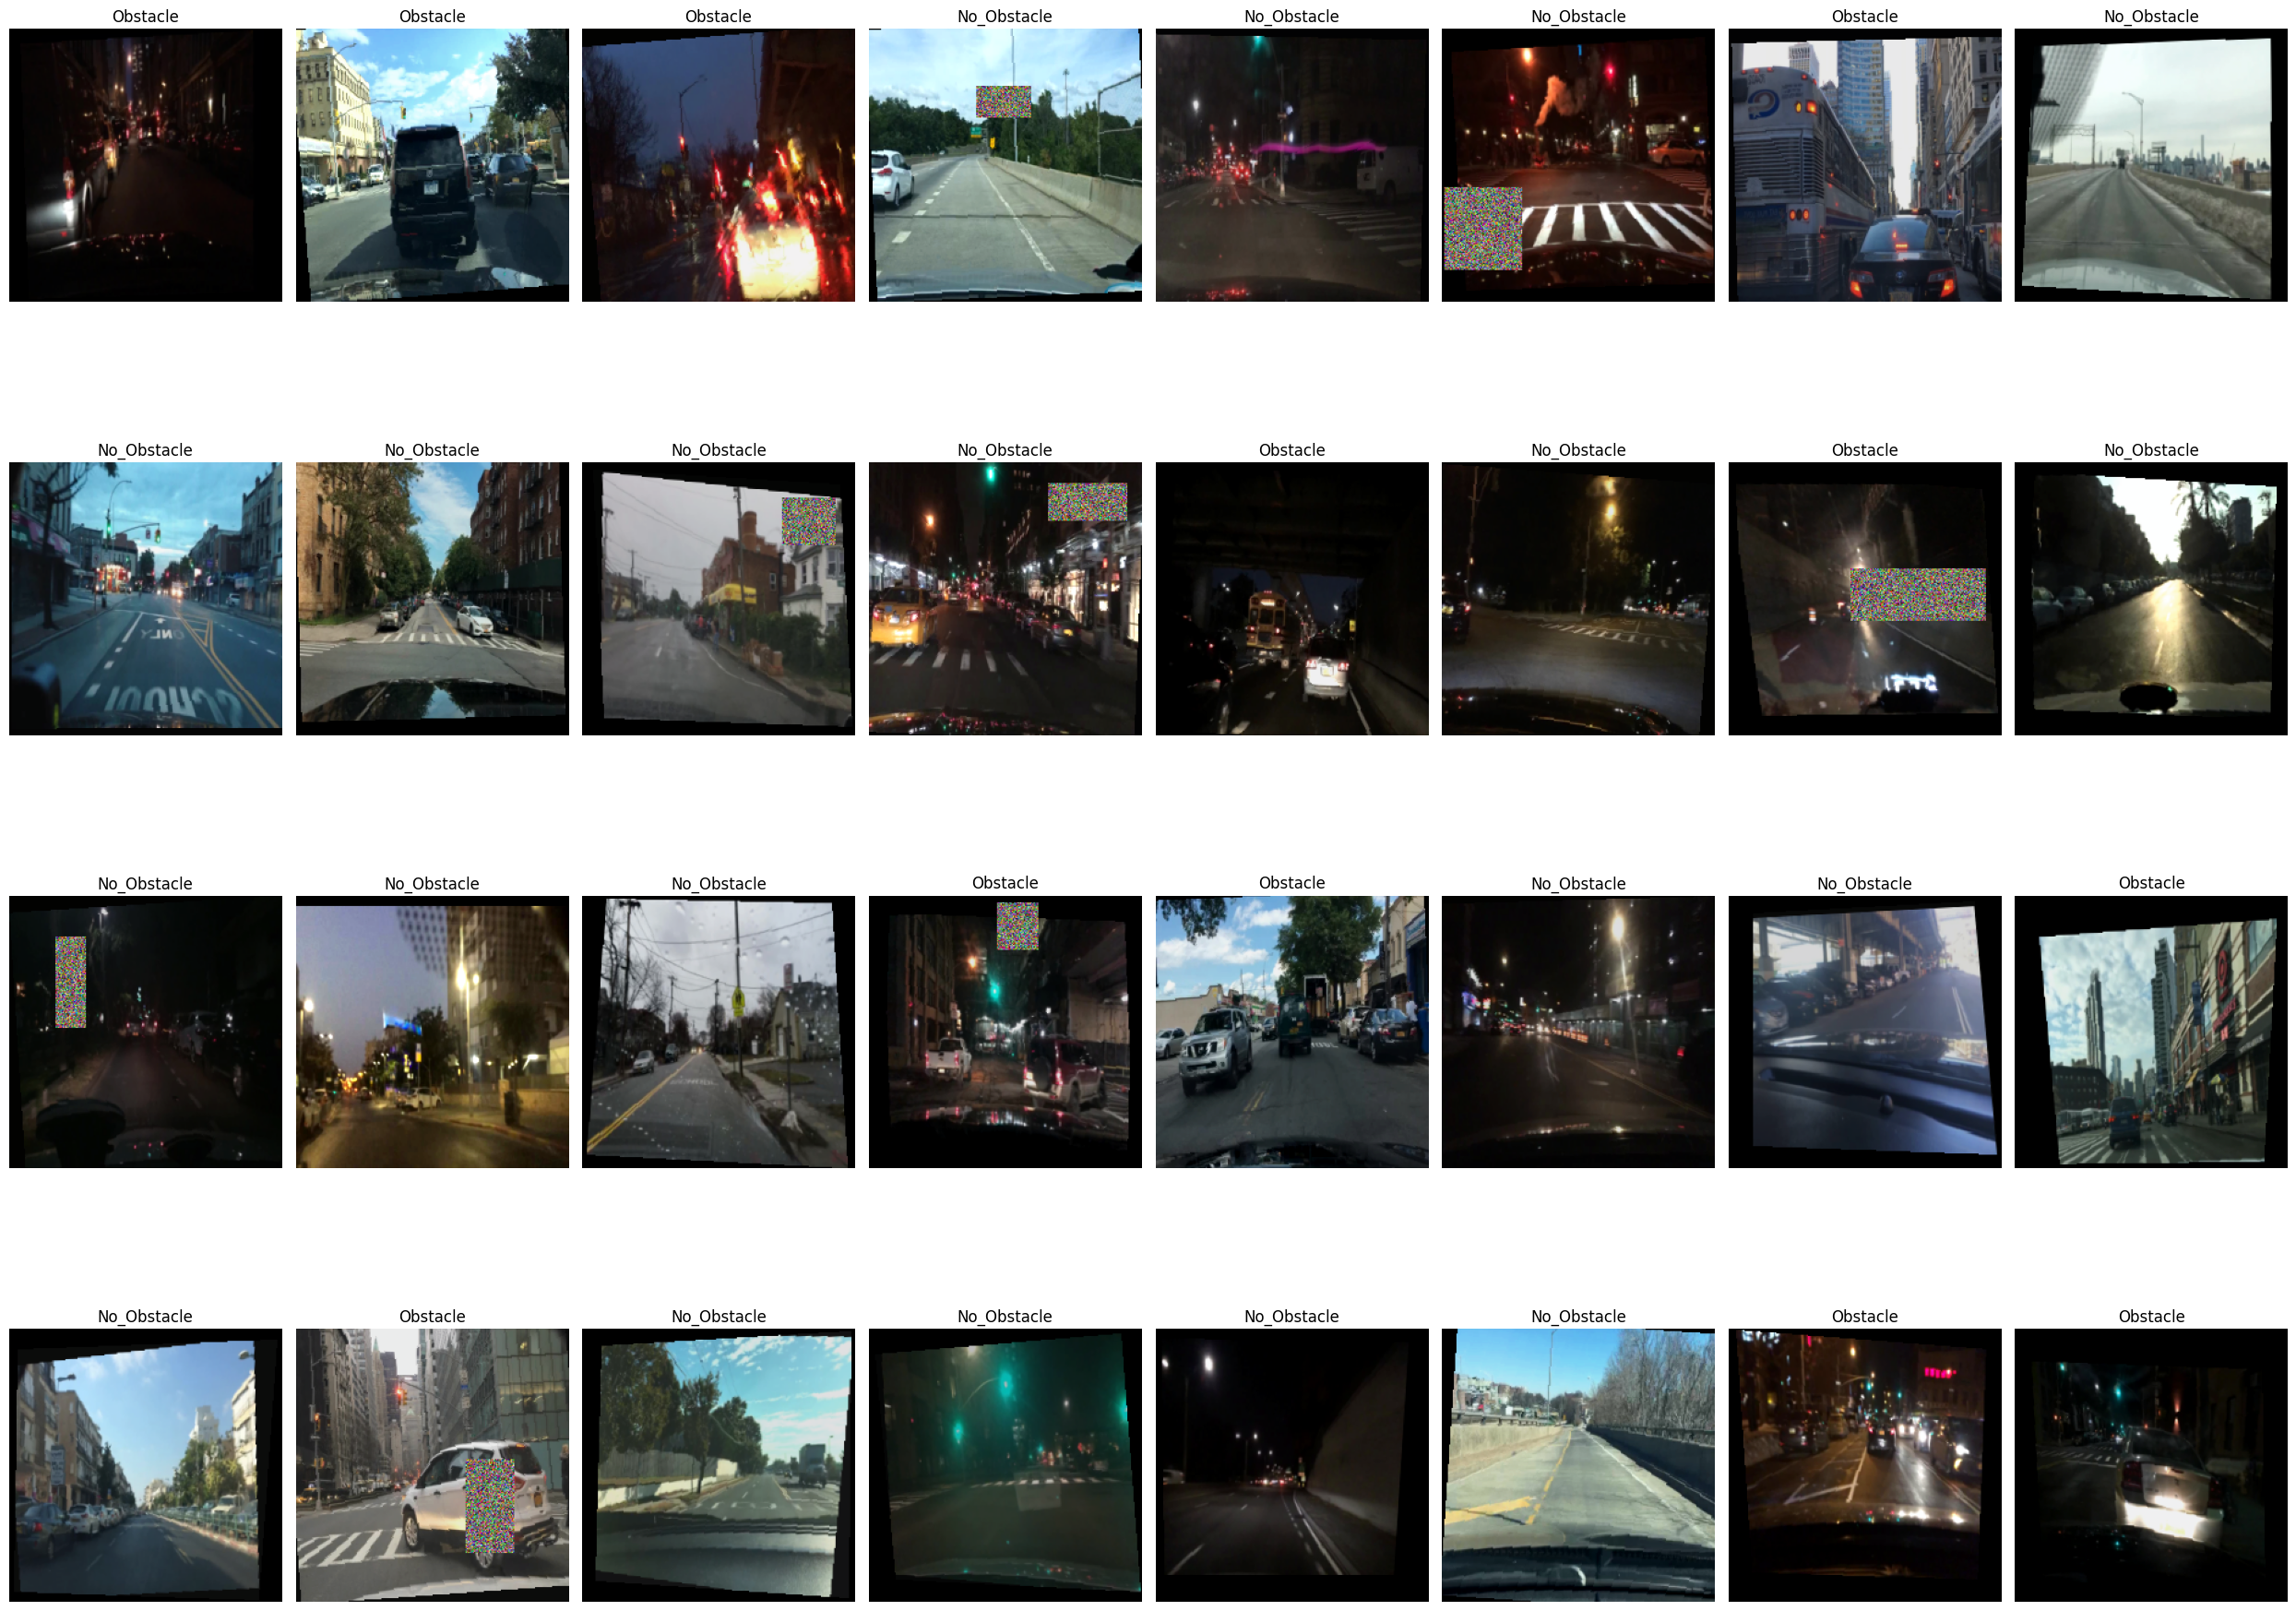

In [24]:
import numpy as np

img_mean = np.array([0.485, 0.456, 0.406])
img_std = np.array([0.229, 0.224, 0.225])

# Fetch the direct string mapping dictionary from your config
mapping = config["classes"]["mapping"]

for images, labels in train_loader:
    images_list = []
    labels_list = []
    for i in range(32):
        img_tensor = images[i].permute(1, 2, 0)
        img_np = img_tensor.numpy() 
        img_np = (img_np * img_std) + img_mean
        img_np = np.clip(img_np, 0, 1)
        label_idx = int(labels[i].item())
        label_text = mapping.get(str(label_idx)) or mapping.get(label_idx)
        
        images_list.append(img_np)
        labels_list.append(label_text)
        
    cr.image_grid(images=images_list, titles=labels_list, rows=4, cols=8)
    break

**val_loader**

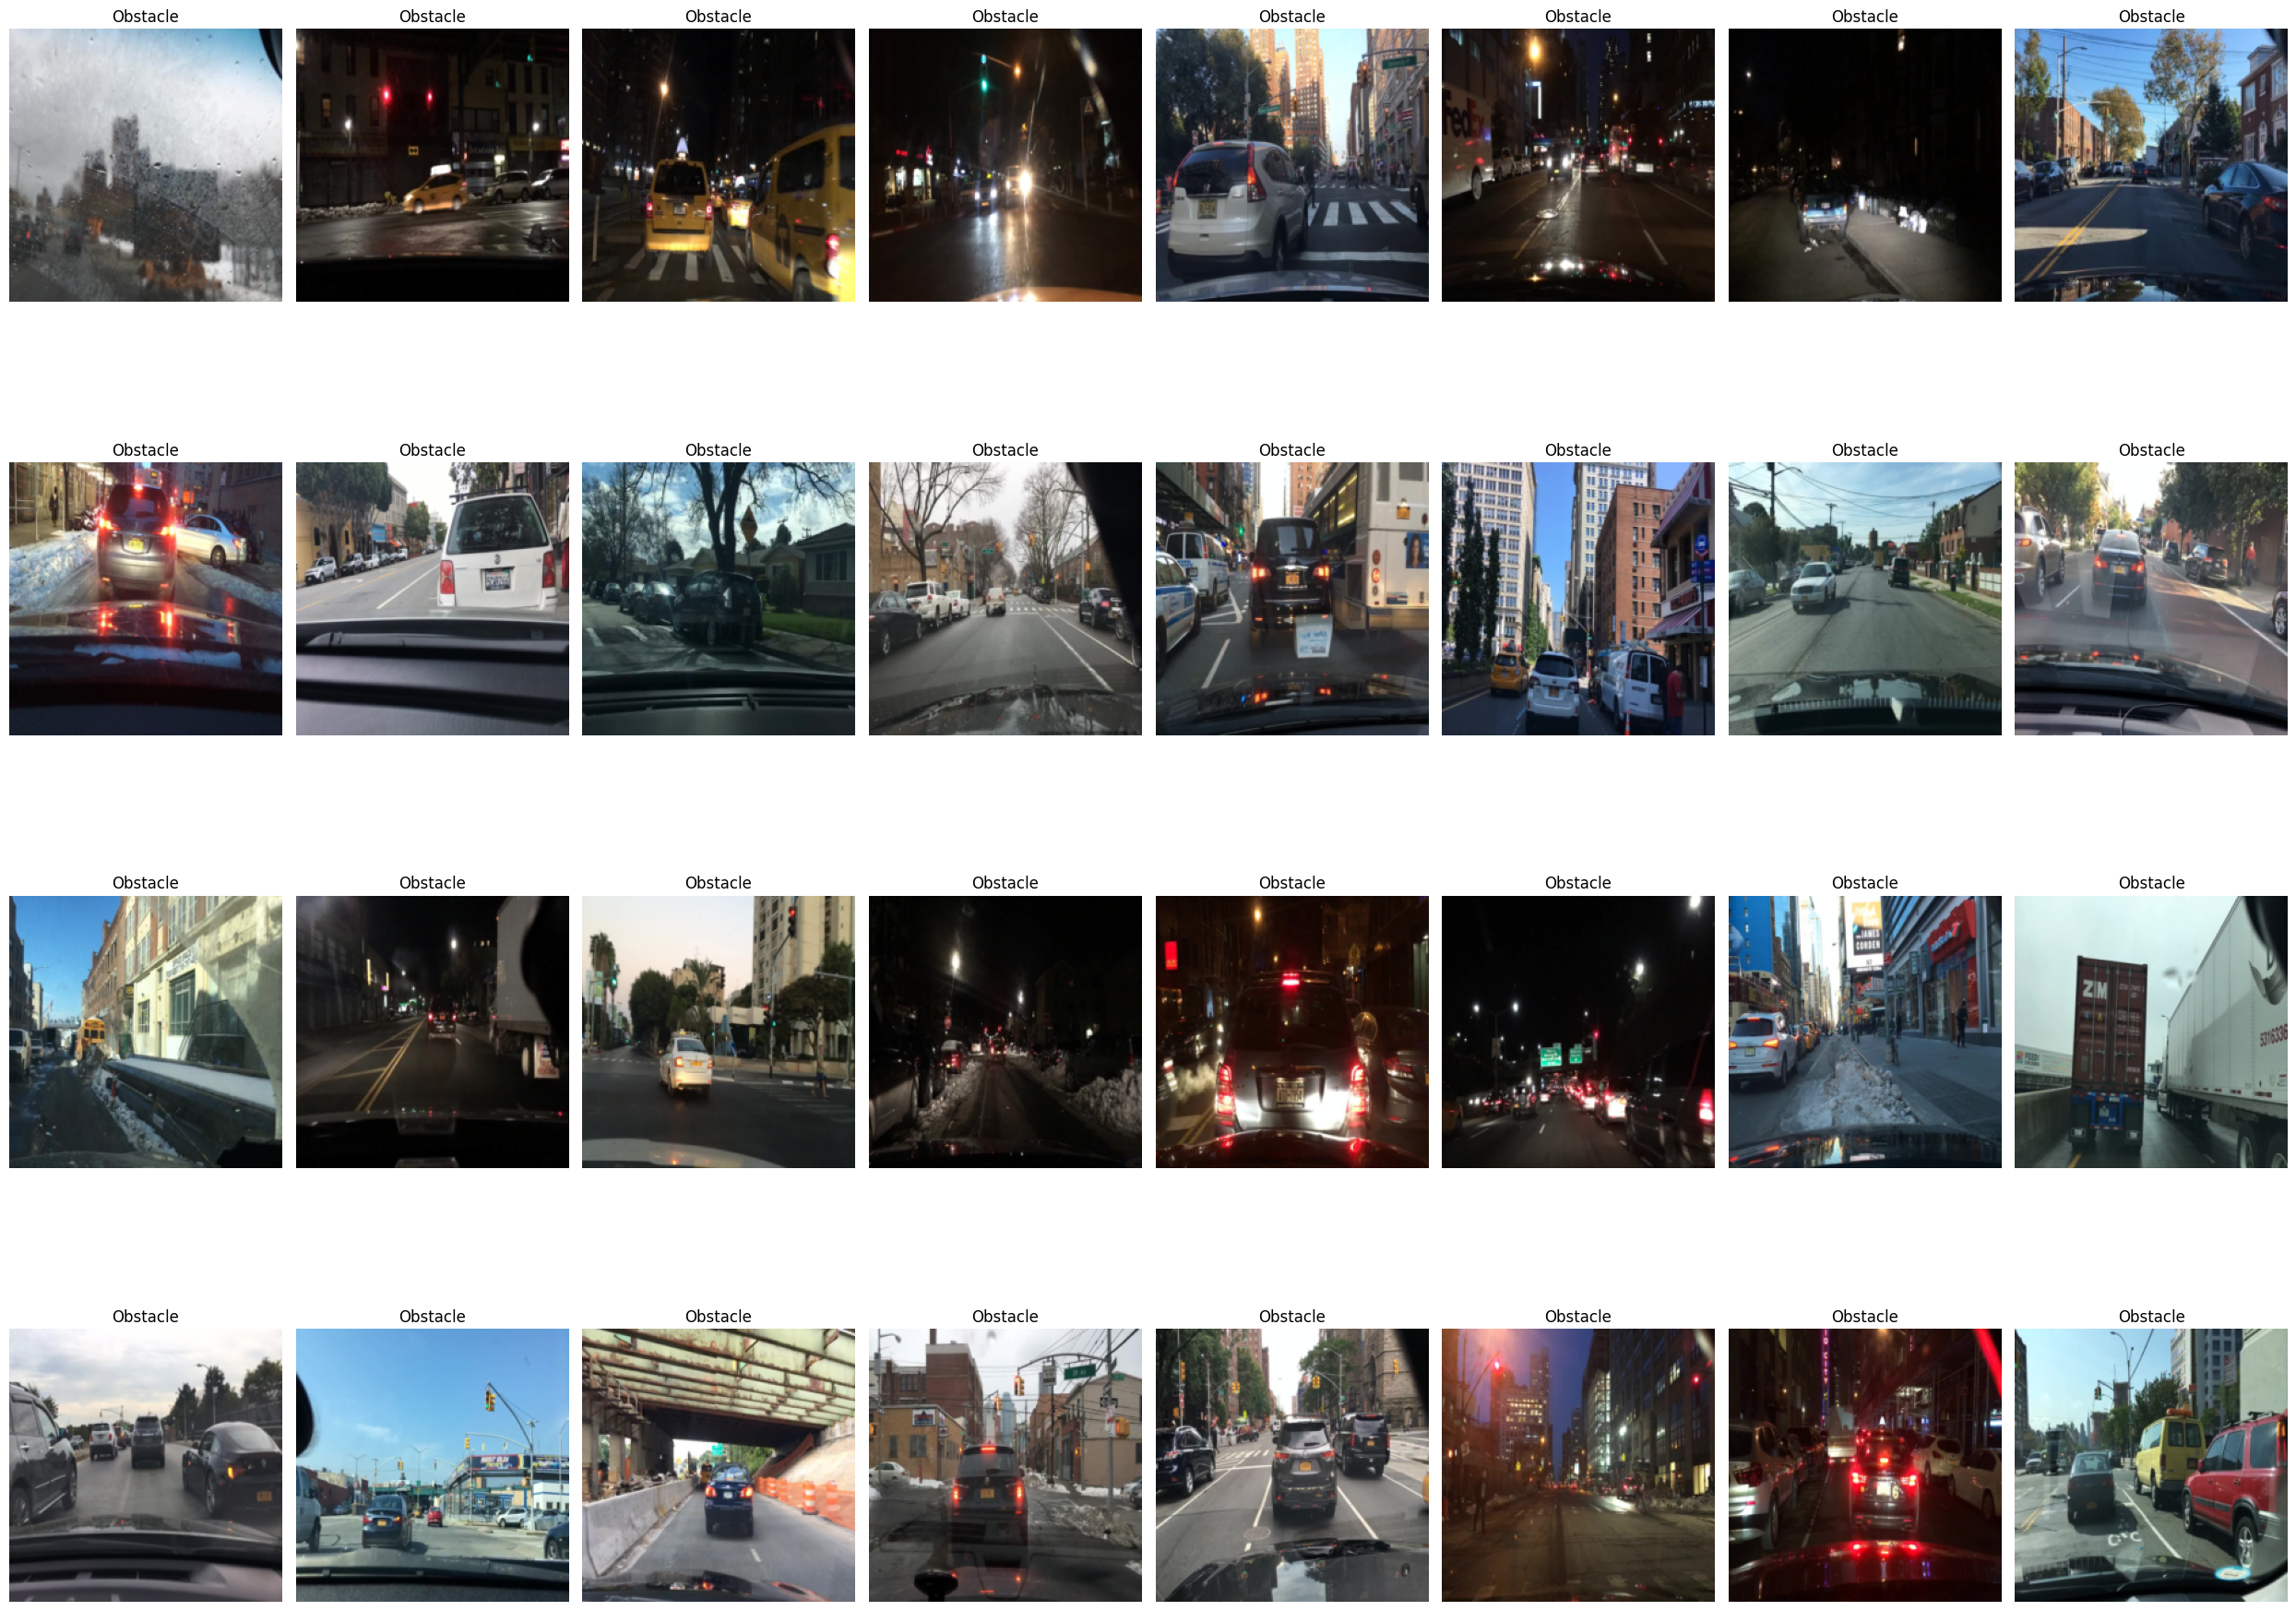

In [25]:
import numpy as np

img_mean = np.array([0.485, 0.456, 0.406])
img_std = np.array([0.229, 0.224, 0.225])

# Fetch the direct string mapping dictionary from your config
mapping = config["classes"]["mapping"]

for images, labels in val_loader:
    images_list = []
    labels_list = []
    for i in range(32):
        img_tensor = images[i].permute(1, 2, 0)
        img_np = img_tensor.numpy() 
        img_np = (img_np * img_std) + img_mean
        img_np = np.clip(img_np, 0, 1)
        label_idx = int(labels[i].item())
        label_text = mapping.get(str(label_idx)) or mapping.get(label_idx)
        
        images_list.append(img_np)
        labels_list.append(label_text)
        
    cr.image_grid(images=images_list, titles=labels_list, rows=4, cols=8)
    break

## Training 

In [26]:
config["model"]["freeze_backbone"] = False
config["training_parameters"]["pos_weights"] = 1.0
config["training_parameters"]["early_stopping_patience"] = 5
config["training_parameters"]["epochs"] = 10
config["model"]["architecture"]="resnet18"
config["training_parameters"]["batch_size"]=128

In [27]:
config_path = "config/config.json"
with open(config_path, "w") as f:
    json.dump(config, f, indent=4)


In [28]:
config

{'paths': {'train_csv': '/kaggle/input/datasets/gracyyadav79/final-csvs/ftrain.csv',
  'val_csv': '/kaggle/input/datasets/gracyyadav79/final-csvs/fval.csv',
  'log_dir': 'logs/',
  'history_dir': 'training_histories/',
  'model_save_dir': 'saved_models/',
  'model_filename': 'best_efficientnet_b0_acc92.0.pthh',
  'model_path': '',
  'experiments_dir': 'experiments'},
 'model': {'architecture': 'resnet18',
  'pretrained': True,
  'num_classes': 1,
  'freeze_backbone': False},
 'classes': {'mapping': {'0': 'No_Obstacle', '1': 'Obstacle'}},
 'training_parameters': {'batch_size': 128,
  'learning_rate': 0.001,
  'epochs': 10,
  'image_size': 224,
  'seed': 1,
  'accumulation_steps': 2,
  'early_stopping_patience': 5,
  'weight_decay': 0.05,
  'pos_weights': 1.0},
 'hardware': {'num_workers': 4}}

In [29]:
len(train_df)

74028

In [30]:
len(val_df)

2182

1. **RESNET18**

In [31]:
!pwd

/kaggle/working/autonomous-binary-classifier


In [32]:
import json
from src.train import run_pipeline

with open("config/config.json", "r") as f:
    config = json.load(f)

config["model"]["architecture"] = "resnet18"

In [33]:
config

{'paths': {'train_csv': '/kaggle/input/datasets/gracyyadav79/final-csvs/ftrain.csv',
  'val_csv': '/kaggle/input/datasets/gracyyadav79/final-csvs/fval.csv',
  'log_dir': 'logs/',
  'history_dir': 'training_histories/',
  'model_save_dir': 'saved_models/',
  'model_filename': 'best_efficientnet_b0_acc92.0.pthh',
  'model_path': '',
  'experiments_dir': 'experiments'},
 'model': {'architecture': 'resnet18',
  'pretrained': True,
  'num_classes': 1,
  'freeze_backbone': False},
 'classes': {'mapping': {'0': 'No_Obstacle', '1': 'Obstacle'}},
 'training_parameters': {'batch_size': 128,
  'learning_rate': 0.001,
  'epochs': 10,
  'image_size': 224,
  'seed': 1,
  'accumulation_steps': 2,
  'early_stopping_patience': 5,
  'weight_decay': 0.05,
  'pos_weights': 1.0},
 'hardware': {'num_workers': 4}}

In [34]:
!python main.py --config="config/config.json"

Experiment directory: experiments/resnet18_lr0.001_bs128_20260810_052851
Configuration saved to: experiments/resnet18_lr0.001_bs128_20260810_052851/config.json
TensorBoard logging to: experiments/resnet18_lr0.001_bs128_20260810_052851/tensorboard
Running on: cuda
Training samples  : 74,028
Validation samples: 2,182
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth
100%|███████████████████████████████████████| 44.7M/44.7M [00:00<00:00, 201MB/s]

--- MODEL ARCHITECTURE SUMMARY ---
Layer (type:depth-idx)                        Output Shape              Param #
AutonomousClassifier                          [128, 1]                  --
├─ResNet: 1-1                                 [128, 512]                --
│    └─Conv2d: 2-1                            [128, 64, 112, 112]       9,408
│    └─BatchNorm2d: 2-2                       [128, 64, 112, 112]       128
│    └─ReLU: 2-3                              [12

In [46]:
!zip -r resnet18_experiment.zip /kaggle/working/autonomous-binary-classifier/experiments/resnet18_*

  adding: kaggle/working/autonomous-binary-classifier/experiments/resnet18_lr0.001_bs128_20260810_052851/ (stored 0%)
  adding: kaggle/working/autonomous-binary-classifier/experiments/resnet18_lr0.001_bs128_20260810_052851/history.json (deflated 67%)
  adding: kaggle/working/autonomous-binary-classifier/experiments/resnet18_lr0.001_bs128_20260810_052851/best_model_acc_91.2.pth (deflated 7%)
  adding: kaggle/working/autonomous-binary-classifier/experiments/resnet18_lr0.001_bs128_20260810_052851/summary.json (deflated 60%)
  adding: kaggle/working/autonomous-binary-classifier/experiments/resnet18_lr0.001_bs128_20260810_052851/tensorboard/ (stored 0%)
  adding: kaggle/working/autonomous-binary-classifier/experiments/resnet18_lr0.001_bs128_20260810_052851/tensorboard/events.out.tfevents.1786339731.156fa2d7597c.226.0 (deflated 19%)
  adding: kaggle/working/autonomous-binary-classifier/experiments/resnet18_lr0.001_bs128_20260810_052851/config.json (deflated 59%)


In [47]:
!find /kaggle/working -name "best_model_acc_*.pth"

/kaggle/working/autonomous-binary-classifier/experiments/resnet18_lr0.001_bs128_20260810_052851/best_model_acc_91.2.pth


2. **EFFICIENTNET_B0**

In [48]:
config["model"]["architecture"]="efficientnet_b0"
config_path = "config/config.json"
with open(config_path, "w") as f:
    json.dump(config, f, indent=4)

In [49]:
config

{'paths': {'train_csv': '/kaggle/input/datasets/gracyyadav79/final-csvs/ftrain.csv',
  'val_csv': '/kaggle/input/datasets/gracyyadav79/final-csvs/fval.csv',
  'log_dir': 'logs/',
  'history_dir': 'training_histories/',
  'model_save_dir': 'saved_models/',
  'model_filename': 'best_efficientnet_b0_acc92.0.pthh',
  'model_path': '',
  'experiments_dir': 'experiments'},
 'model': {'architecture': 'efficientnet_b0',
  'pretrained': True,
  'num_classes': 1,
  'freeze_backbone': False},
 'classes': {'mapping': {'0': 'No_Obstacle', '1': 'Obstacle'}},
 'training_parameters': {'batch_size': 128,
  'learning_rate': 0.001,
  'epochs': 10,
  'image_size': 224,
  'seed': 1,
  'accumulation_steps': 2,
  'early_stopping_patience': 5,
  'weight_decay': 0.05,
  'pos_weights': 1.0},
 'hardware': {'num_workers': 4}}

In [50]:
!python main.py --config="config/config.json"

Experiment directory: experiments/efficientnet_b0_lr0.001_bs128_20260810_071818
Configuration saved to: experiments/efficientnet_b0_lr0.001_bs128_20260810_071818/config.json
TensorBoard logging to: experiments/efficientnet_b0_lr0.001_bs128_20260810_071818/tensorboard
Running on: cuda
Training samples  : 74,028
Validation samples: 2,182

--- MODEL ARCHITECTURE SUMMARY ---
Layer (type:depth-idx)                                       Output Shape              Param #
AutonomousClassifier                                         [128, 1]                  --
├─EfficientNet: 1-1                                          [128, 1280]               --
│    └─Sequential: 2-1                                       [128, 1280, 7, 7]         --
│    │    └─Conv2dNormActivation: 3-1                        [128, 32, 112, 112]       928
│    │    └─Sequential: 3-2                                  [128, 16, 112, 112]       1,448
│    │    └─Sequential: 3-3                                  [128, 24, 56, 56

In [60]:
!zip -r efficientnet_experiment.zip /kaggle/working/autonomous-binary-classifier/experiments/efficientnet_b0_*

updating: kaggle/working/autonomous-binary-classifier/experiments/efficientnet_b0_lr0.001_bs128_20260810_070209/ (stored 0%)
updating: kaggle/working/autonomous-binary-classifier/experiments/efficientnet_b0_lr0.001_bs128_20260810_070209/tensorboard/ (stored 0%)
updating: kaggle/working/autonomous-binary-classifier/experiments/efficientnet_b0_lr0.001_bs128_20260810_070209/tensorboard/events.out.tfevents.1786345329.156fa2d7597c.614.0 (deflated 9%)
updating: kaggle/working/autonomous-binary-classifier/experiments/efficientnet_b0_lr0.001_bs128_20260810_070209/config.json (deflated 60%)
updating: kaggle/working/autonomous-binary-classifier/experiments/efficientnet_b0_lr0.001_bs128_20260810_071818/ (stored 0%)
updating: kaggle/working/autonomous-binary-classifier/experiments/efficientnet_b0_lr0.001_bs128_20260810_071818/history.json (deflated 68%)
updating: kaggle/working/autonomous-binary-classifier/experiments/efficientnet_b0_lr0.001_bs128_20260810_071818/summary.json (deflated 62%)
updati

3. **MOBILENET_V3**

In [53]:
config["model"]["architecture"]="mobilenet_v3"
config_path = "config/config.json"
with open(config_path, "w") as f:
    json.dump(config, f, indent=4)

In [61]:
config

{'paths': {'train_csv': '/kaggle/input/datasets/gracyyadav79/final-csvs/ftrain.csv',
  'val_csv': '/kaggle/input/datasets/gracyyadav79/final-csvs/fval.csv',
  'log_dir': 'logs/',
  'history_dir': 'training_histories/',
  'model_save_dir': 'saved_models/',
  'model_filename': 'best_efficientnet_b0_acc92.0.pthh',
  'model_path': '',
  'experiments_dir': 'experiments'},
 'model': {'architecture': 'mobilenet_v3',
  'pretrained': True,
  'num_classes': 1,
  'freeze_backbone': False},
 'classes': {'mapping': {'0': 'No_Obstacle', '1': 'Obstacle'}},
 'training_parameters': {'batch_size': 128,
  'learning_rate': 0.001,
  'epochs': 10,
  'image_size': 224,
  'seed': 1,
  'accumulation_steps': 2,
  'early_stopping_patience': 5,
  'weight_decay': 0.05,
  'pos_weights': 1.0},
 'hardware': {'num_workers': 4}}

In [54]:
!python main.py --config="config/config.json"

Experiment directory: experiments/mobilenet_v3_lr0.001_bs128_20260810_085636
Configuration saved to: experiments/mobilenet_v3_lr0.001_bs128_20260810_085636/config.json
TensorBoard logging to: experiments/mobilenet_v3_lr0.001_bs128_20260810_085636/tensorboard
Running on: cuda
Training samples  : 74,028
Validation samples: 2,182
Downloading: "https://download.pytorch.org/models/mobilenet_v3_small-047dcff4.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v3_small-047dcff4.pth
100%|███████████████████████████████████████| 9.83M/9.83M [00:00<00:00, 161MB/s]

--- MODEL ARCHITECTURE SUMMARY ---
Layer (type:depth-idx)                                  Output Shape              Param #
AutonomousClassifier                                    [128, 1]                  --
├─MobileNetV3: 1-1                                      [128, 576]                --
│    └─Sequential: 2-1                                  [128, 576, 7, 7]          --
│    │    └─Conv2dNormActivation: 3-1                   

In [59]:
!zip -r mobilenet_experiment.zip /kaggle/working/autonomous-binary-classifier/experiments/mobilenet_v3_*

  adding: kaggle/working/autonomous-binary-classifier/experiments/mobilenet_v3_lr0.001_bs128_20260810_085636/ (stored 0%)
  adding: kaggle/working/autonomous-binary-classifier/experiments/mobilenet_v3_lr0.001_bs128_20260810_085636/history.json (deflated 67%)
  adding: kaggle/working/autonomous-binary-classifier/experiments/mobilenet_v3_lr0.001_bs128_20260810_085636/summary.json (deflated 61%)
  adding: kaggle/working/autonomous-binary-classifier/experiments/mobilenet_v3_lr0.001_bs128_20260810_085636/tensorboard/ (stored 0%)
  adding: kaggle/working/autonomous-binary-classifier/experiments/mobilenet_v3_lr0.001_bs128_20260810_085636/tensorboard/events.out.tfevents.1786352196.156fa2d7597c.1055.0 (deflated 19%)
  adding: kaggle/working/autonomous-binary-classifier/experiments/mobilenet_v3_lr0.001_bs128_20260810_085636/config.json (deflated 59%)
  adding: kaggle/working/autonomous-binary-classifier/experiments/mobilenet_v3_lr0.001_bs128_20260810_085636/best_model_acc_91.3.pth (deflated 8%)


## Training Logs 
Collect the traingin history for all three models, including :
* training loss
* validation loss
* training accuracy
* validation accuracy

In [62]:
!find /kaggle/working/autonomous-binary-classifier/experiments -maxdepth 2 -type f

/kaggle/working/autonomous-binary-classifier/experiments/mobilenet_v3_lr0.001_bs128_20260810_085636/history.json
/kaggle/working/autonomous-binary-classifier/experiments/mobilenet_v3_lr0.001_bs128_20260810_085636/summary.json
/kaggle/working/autonomous-binary-classifier/experiments/mobilenet_v3_lr0.001_bs128_20260810_085636/config.json
/kaggle/working/autonomous-binary-classifier/experiments/mobilenet_v3_lr0.001_bs128_20260810_085636/best_model_acc_91.3.pth
/kaggle/working/autonomous-binary-classifier/experiments/efficientnet_b0_lr0.001_bs128_20260810_070209/config.json
/kaggle/working/autonomous-binary-classifier/experiments/efficientnet_b0_lr0.001_bs128_20260810_071818/history.json
/kaggle/working/autonomous-binary-classifier/experiments/efficientnet_b0_lr0.001_bs128_20260810_071818/summary.json
/kaggle/working/autonomous-binary-classifier/experiments/efficientnet_b0_lr0.001_bs128_20260810_071818/config.json
/kaggle/working/autonomous-binary-classifier/experiments/efficientnet_b0_lr0

In [63]:
!zip -r all_experiments.zip /kaggle/working/autonomous-binary-classifier/experiments/

  adding: kaggle/working/autonomous-binary-classifier/experiments/ (stored 0%)
  adding: kaggle/working/autonomous-binary-classifier/experiments/mobilenet_v3_lr0.001_bs128_20260810_085636/ (stored 0%)
  adding: kaggle/working/autonomous-binary-classifier/experiments/mobilenet_v3_lr0.001_bs128_20260810_085636/history.json (deflated 67%)
  adding: kaggle/working/autonomous-binary-classifier/experiments/mobilenet_v3_lr0.001_bs128_20260810_085636/summary.json (deflated 61%)
  adding: kaggle/working/autonomous-binary-classifier/experiments/mobilenet_v3_lr0.001_bs128_20260810_085636/tensorboard/ (stored 0%)
  adding: kaggle/working/autonomous-binary-classifier/experiments/mobilenet_v3_lr0.001_bs128_20260810_085636/tensorboard/events.out.tfevents.1786352196.156fa2d7597c.1055.0 (deflated 19%)
  adding: kaggle/working/autonomous-binary-classifier/experiments/mobilenet_v3_lr0.001_bs128_20260810_085636/config.json (deflated 59%)
  adding: kaggle/working/autonomous-binary-classifier/experiments/mo

## Summary

All three models have now been trained on the same dataset under the same conditions 